In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [31]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.

In [33]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [34]:
data.columns

Index(['와인_종류', '알코올_도수', '사과산_함량', '재_함량', '재의_알칼리도', '마그네슘_함량', '총_페놀_함량',
       '플라보노이드_함량', '비플라보노이드_페놀_함량', '프로안토시아닌_함량', '색_강도', '색조',
       '희석_와인의_투과율_OD280_OD315', '프롤린_함량'],
      dtype='object')

<Axes: >

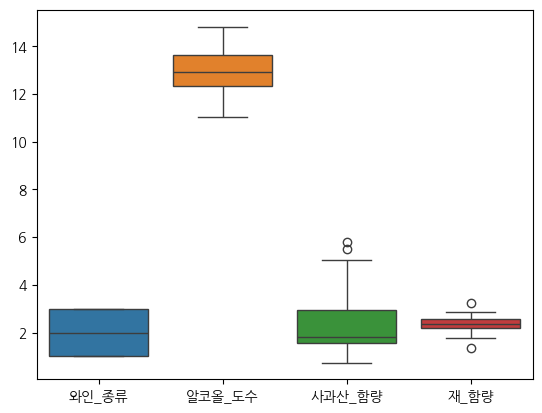

In [35]:
sns.boxplot(data.iloc[:,0:4])

<Axes: ylabel='마그네슘_함량'>

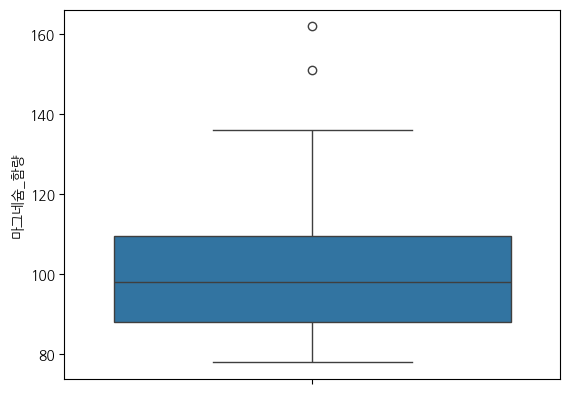

In [36]:
sns.boxplot(data.iloc[:,5])

<Axes: >

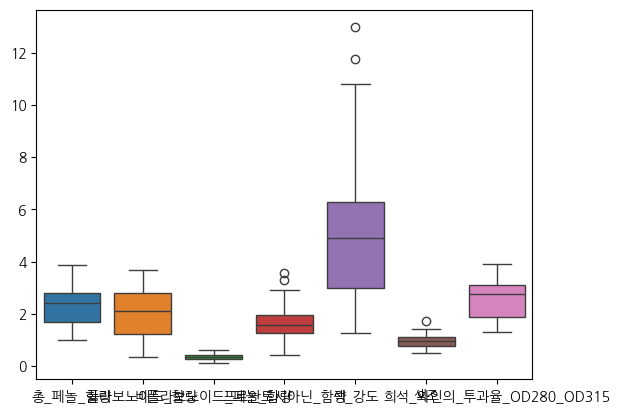

In [37]:
sns.boxplot(data.iloc[:,6:-1])

따로 정리할 데이터가 없으므로 바로 진행

In [38]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

In [42]:
mms_X_test

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
61,0.486842,0.424180,0.559140,0.573171,0.256410,0.019231,0.228125,0.22,0.143357,0.351536,0.211382,0.034749,0.203719
63,0.331579,0.141393,0.456989,0.597561,0.243590,-0.057692,0.165625,0.48,0.363636,0.151024,0.346341,0.189189,0.478577
3,0.744737,0.120902,0.704301,0.878049,0.025641,0.653846,0.740625,0.16,0.506993,0.179181,0.715447,0.706564,0.106710
40,0.331579,0.461066,0.456989,0.451220,0.051282,0.615385,0.781250,0.64,0.835664,0.087031,0.764228,0.579151,0.103476
97,0.750000,0.844262,0.467742,0.573171,-0.051282,-0.103846,-0.046875,0.54,0.090909,0.308874,0.081301,0.000000,0.110752
81,0.439474,0.538934,0.537634,0.664634,0.282051,0.173077,0.221875,0.08,0.146853,0.317406,0.243902,-0.015444,0.260307
78,0.650000,0.450820,0.677419,0.817073,0.500000,0.057692,0.337500,0.18,0.290210,0.624573,0.089431,-0.011583,0.179466
95,0.276316,0.186475,0.516129,0.481707,-0.038462,0.134615,0.315625,0.78,0.426573,0.095563,0.487805,0.362934,0.163298
65,0.613158,0.336066,0.532258,0.573171,0.064103,0.057692,0.003125,0.48,0.076923,0.368601,0.178862,0.440154,0.405821
57,0.721053,0.200820,0.709677,0.396341,0.397436,0.673077,0.718750,0.52,0.440559,0.428328,0.528455,0.617761,0.886823


In [43]:
y_train.value_counts()

와인_종류
2    29
1    25
3    20
Name: count, dtype: int64

와인의 종류가 3가지이므로 조작이 필요

In [44]:
# one-hot 인코딩
y_train = pd.get_dummies(y_train)
y_train

,1,2,3
79,False,False,True
54,False,True,False
98,True,False,False
20,False,True,False
92,False,False,True
...,...,...,...
43,True,False,False
16,False,True,False
59,False,False,True
37,False,True,False


In [45]:
y_test = pd.get_dummies(y_test)
y_test

,1,2,3
61,False,False,True
63,False,True,False
3,False,True,False
40,False,True,False
97,False,False,True
81,False,False,True
78,False,False,True
95,False,True,False
65,False,False,True
57,True,False,False


In [53]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [54]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step - accuracy: 0.2620 - loss: 1.1610 - val_accuracy: 0.2812 - val_loss: 1.1231
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2819 - loss: 1.1148 - val_accuracy: 0.2812 - val_loss: 1.0990
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2932 - loss: 1.0817 - val_accuracy: 0.2812 - val_loss: 1.0804
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3045 - loss: 1.0616 - val_accuracy: 0.2812 - val_loss: 1.0657
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2842 - loss: 1.0573 - val_accuracy: 0.4375 - val_loss: 1.0533
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4516 - loss: 1.0520 - val_accuracy: 0.5938 - val_loss: 1.0429
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5992 - loss: 1.0361 - val_accuracy: 0.5938 - val_loss: 1.0326
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5873 - loss: 1.0240 - val_accuracy: 0.5938 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9771 - loss: 0.3204 - val_accuracy: 0.9375 - val_loss: 0.3724
Epoch 52/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9849 - loss: 0.2841 - val_accuracy: 0.9375 - val_loss: 0.3623
Epoch 53/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9788 - loss: 0.2769 - val_accuracy: 0.9375 - val_loss: 0.3528
Epoch 54/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9955 - loss: 0.2530 - val_accuracy: 0.9375 - val_loss: 0.3438
Epoch 55/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9738 - loss: 0.2859 - val_accuracy: 0.9375 - val_loss: 0.3331
Epoch 56/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9738 - loss: 0.3008 - val_accuracy: 0.9375 - val_loss: 0.3232
Epoch 57/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9738 - loss: 0.2392 - val_accuracy: 0.9375 - val_loss: 0.3139
Epoch 58/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9929 - loss: 0.2311 - val_accuracy: 0.9375 - val_los

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0380 - val_accuracy: 0.9688 - val_loss: 0.1217
Epoch 102/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0305 - val_accuracy: 0.9688 - val_loss: 0.1206
Epoch 103/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0333 - val_accuracy: 0.9688 - val_loss: 0.1177
Epoch 104/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0308 - val_accuracy: 0.9688 - val_loss: 0.1183
Epoch 105/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0327 - val_accuracy: 0.9688 - val_loss: 0.1155
Epoch 106/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0313 - val_accuracy: 0.9688 - val_loss: 0.1152
Epoch 107/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0297 - val_accuracy: 0.9688 - val_loss: 0.1162
Epoch 108/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0298 - val_accuracy: 0.9688 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9688 - val_loss: 0.1174
Epoch 152/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.9688 - val_loss: 0.1184
Epoch 153/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9688 - val_loss: 0.1185
Epoch 154/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.9688 - val_loss: 0.1178
Epoch 155/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9688 - val_loss: 0.1172
Epoch 156/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.9688 - val_loss: 0.1178
Epoch 157/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.9688 - val_loss: 0.1183
Epoch 158/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.9688 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9688 - val_loss: 0.1237
Epoch 202/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9688 - val_loss: 0.1241
Epoch 203/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9688 - val_loss: 0.1244
Epoch 204/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9688 - val_loss: 0.1241
Epoch 205/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.9688 - val_loss: 0.1224
Epoch 206/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9688 - val_loss: 0.1242
Epoch 207/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9688 - val_loss: 0.1245
Epoch 208/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9688 - 

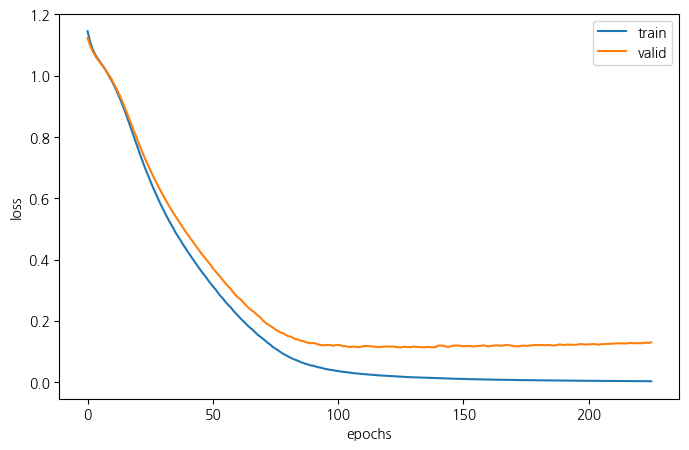

In [55]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(patience=100)
file_path = "./model/wine_loss_{val_loss:.4f}_epoch_{epoch:04d}.keras"
model_save= ModelCheckpoint(filepath=file_path, save_best_only=True)

history = model.fit(mms_X_train, y_train,
                   epochs=1000,
                   batch_size=16,
                   validation_data=(mms_X_test, y_test),
                   callbacks=[early_stop, model_save])

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

In [49]:
from keras.models import load_model

In [56]:
best_model = load_model("./model/wine_loss_0.1135_epoch_0126.keras")
pred2 = best_model.evaluate(mms_X_test, y_test)
print("loss: ", pred2[0], "accuracy: ", pred2[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9688 - loss: 0.1135
loss:  0.1135237067937851 accuracy:  0.96875
